# How long before the 6 May 2024 Osage County tornado was a tornado warning issued?

An EF4 tornado struck Osage County, Oklahoma on the evening of 6 May 2024.
This study pins two inputs: every NWS watch, warning, and advisory issued for
the county that evening, and the 2024 Storm Events archive, which holds the
report of the tornado. Setting each warning's issuance beside the report's
start time gives a lead time, and shows what a county-level record can and
cannot say about it.

It needs `usdata[pandas]` and matplotlib. The first run downloads about
13 MB, almost all of it the year's Storm Events archive, and takes a few
seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T06:06:29+00:00
usdata 0.26.0; pandas 3.0.6


## Data

- [NWS watches, warnings, and advisories](https://usdata.dev/datasets/noaa/nws-vtec-events/),
  named `warnings`: one row per VTEC event, from the Iowa Environmental
  Mesonet's archive of the NWS product stream. The source is selected by an
  exact county: `Osage County, OK` becomes the NWS code `OKC113`, the state's
  postal code, `C`, and the county FIPS code. A bounding box could not do
  that, and is refused.
- [Storm Events](https://usdata.dev/datasets/noaa/storm-events/), named
  `reports`: NCEI's archive of reported storms, for the tornado's start and
  end times. It is published as one file per year, so the one-day window
  selects the whole 2024 file.

The warnings window selects events by when they were **issued**, not by when
they were in effect. To ask what was in effect at some moment, the window has
to reach back far enough to catch everything still running, as this one does
from 18:00 UTC.

In [2]:
print(manifest.read_text())

name: osage-tornado-warning-lead-time
sources:
  - name: warnings
    dataset: noaa:nws-vtec-events
    location: Osage County, OK
    start: 2024-05-06T18:00Z
    end: 2024-05-07T12:00Z
  - name: reports
    dataset: noaa:storm-events
    start: 2024-05-06
    end: 2024-05-06



In [3]:
result = pull(manifest)
for item in result.fetched:
    print(item.asset.dataset_id)
    print(f"File: {item.path.name}")
    print(f"Bytes: {item.provenance.size}; cache hit: {item.from_cache}")
    print("Source:", item.provenance.source_url)
    print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
    print("Checksum:", item.provenance.checksum)
    print()

noaa:nws-vtec-events
File: vtec_OKC113_20240506_20240507_9048c17737f26bcb97ac.csv
Bytes: 3571; cache hit: False
Source: https://mesonet.agron.iastate.edu/json/vtec_events_byugc.py?ugc=OKC113&sts=2024-05-06T18%3A00%3A00Z&ets=2024-05-07T12%3A00%3A01Z&fmt=csv
Retrieved (UTC): 2026-09-24T06:06:29+00:00
Checksum: sha256:1afb1397a85ffb0b5b0234c29d0a55176ee1b5ac24de1690c8832e5c3a0691a5

noaa:storm-events
File: StormEvents_details-ftp_v1.0_d2024_c20260728.csv.gz
Bytes: 12693243; cache hit: False
Source: https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d2024_c20260728.csv.gz
Retrieved (UTC): 2026-09-24T06:06:41+00:00
Checksum: sha256:2070b83eccab041b36360ab73645b9a249c3eefc5b92b5b3fc0cbba4d9fcc09c



## The tornado

Storm Events gives each report's start and end in the county's local standard
time; the reader adds `BEGIN_UTC` and `END_UTC`. Event 1184254 is the EF4's
Osage County segment.

In [4]:
warnings = result.one("warnings").open(parse_dates=["iso_issued", "iso_expired"])
reports = result.one("reports").open()
print(f"Storm Events rows for 2024: {len(reports):,}")
tornado = reports[reports["EVENT_ID"] == "1184254"].iloc[0]
start, end = tornado["BEGIN_UTC"], tornado["END_UTC"]
columns = ["EVENT_ID", "EVENT_TYPE", "TOR_F_SCALE", "CZ_NAME", "BEGIN_DATE_TIME"]
columns += ["CZ_TIMEZONE", "BEGIN_UTC", "END_UTC", "TOR_LENGTH", "TOR_OTHER_CZ_NAME"]
tornado[columns].to_frame("value")

Storm Events rows for 2024: 69,801


,value
EVENT_ID,1184254
EVENT_TYPE,Tornado
TOR_F_SCALE,EF4
CZ_NAME,OSAGE
BEGIN_DATE_TIME,06-MAY-24 20:12:00
CZ_TIMEZONE,CST-6
BEGIN_UTC,2024-05-07 02:12:00+00:00
END_UTC,2024-05-07 02:57:00+00:00
TOR_LENGTH,32.4
TOR_OTHER_CZ_NAME,WASHINGTON


The report starts the tornado at 20:12 CST on 6 May, which is 02:12 UTC on
7 May, and ends it at 02:57 UTC, 4 miles east-northeast of Osage to 7 miles
east of Okesa. It continued into Washington County as a second segment.

## The county's evening

Every event issued for the county between 18:00 UTC on 6 May and 12:00 UTC on
7 May, by type and office.

In [5]:
print(f"{len(warnings)} events, from office(s): {sorted(warnings['wfo'].unique())}")
warnings.groupby(["ph_name", "sig_name"]).size().rename("events").to_frame()

14 events, from office(s): ['TSA']


events
ph_name             sig_name        
Flash Flood         Warning        1
Flood               Advisory       1
Severe Thunderstorm Warning        7
Tornado             Warning        4
                    Watch          1

## Which warning was in effect

Set each Tornado Warning's issuance and expiry beside the report's start.
`iso_issued` and `iso_expired` are the timezone-aware pair; `issued` and
`expired` hold the same instants in a second format.

In [6]:
tornado_warnings = warnings[
    (warnings["phenomena"] == "TO") & (warnings["significance"] == "W")
].sort_values("iso_issued")
minutes = pd.Timedelta(minutes=1)
table = pd.DataFrame(
    {
        "warning": tornado_warnings["eventid"],
        "issued (UTC)": tornado_warnings["iso_issued"].dt.strftime("%H:%M"),
        "expired (UTC)": tornado_warnings["iso_expired"].dt.strftime("%H:%M"),
        "issued, min before start": (start - tornado_warnings["iso_issued"]) // minutes,
        "expired, min after start": (tornado_warnings["iso_expired"] - start) // minutes,
        "in effect at start": (tornado_warnings["iso_issued"] <= start)
        & (tornado_warnings["iso_expired"] > start),
    }
).set_index("warning")
table

,issued (UTC),expired (UTC),"issued, min before start","expired, min after start",in effect at start
warning,,,,,
44,01:34,02:00,38,-12,False
45,01:56,02:45,16,33,True
46,02:14,02:45,-2,33,False
47,02:35,03:15,-23,63,False


In [7]:
in_effect = tornado_warnings[
    (tornado_warnings["iso_issued"] <= start) & (tornado_warnings["iso_expired"] > start)
]
lead = start - in_effect["iso_issued"].min()

# Walk back from the start through overlapping tornado warnings to find how long
# some tornado warning naming the county had been continuously in effect.
covered_since = in_effect["iso_issued"].min()
for issued, expired in zip(
    tornado_warnings["iso_issued"][::-1], tornado_warnings["iso_expired"][::-1], strict=True
):
    if issued < covered_since <= expired:
        covered_since = issued
watch = warnings[(warnings["phenomena"] == "TO") & (warnings["significance"] == "A")].iloc[0]

print(f"The EF4 began at {start:%H:%M} UTC on {start:%d %B %Y}.")
print(
    f"Tornado Warning {in_effect['eventid'].iloc[0]} was in effect, "
    f"issued {lead // minutes} minutes earlier."
)
print(
    f"A tornado warning naming the county had been in effect continuously since "
    f"{covered_since:%H:%M} UTC, {(start - covered_since) // minutes} minutes before."
)
print(
    f"The Tornado Watch was issued at {watch['iso_issued']:%H:%M} UTC, "
    f"{(start - watch['iso_issued']) / pd.Timedelta(hours=1):.1f} hours before."
)

The EF4 began at 02:12 UTC on 07 May 2024.
Tornado Warning 45 was in effect, issued 16 minutes earlier.
A tornado warning naming the county had been in effect continuously since 01:34 UTC, 38 minutes before.
The Tornado Watch was issued at 19:05 UTC, 7.1 hours before.


Every Osage County alert running between 01:00 and 04:00 UTC on 7 May, with
the tornado's time on the ground shaded.

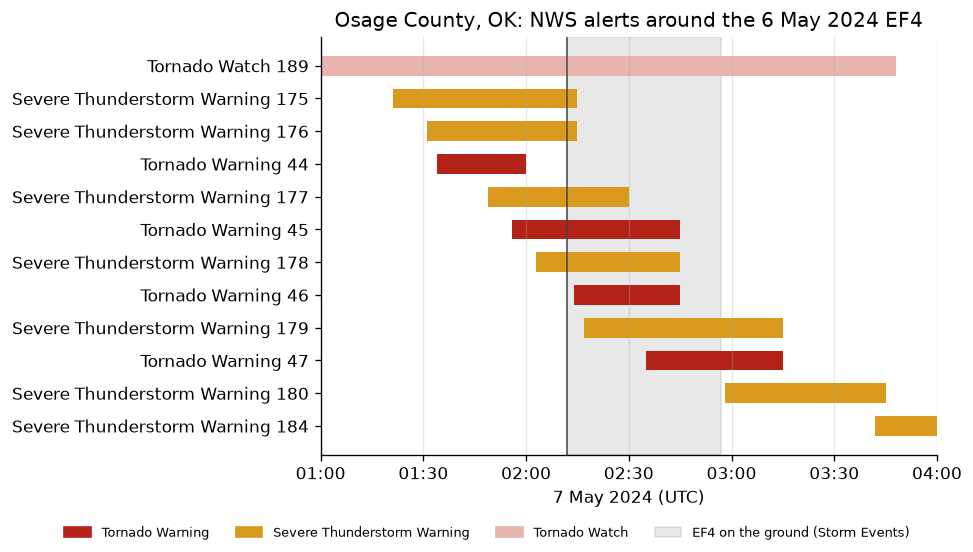

In [8]:
window_start = pd.Timestamp("2024-05-07T01:00Z")
window_end = pd.Timestamp("2024-05-07T04:00Z")
shown = warnings[
    (warnings["iso_expired"] > window_start) & (warnings["iso_issued"] < window_end)
].sort_values("iso_issued", ascending=False)
colors = {("TO", "W"): "#b42318", ("SV", "W"): "#d99a1e", ("TO", "A"): "#e8b4ae"}

fig, ax = plt.subplots(layout="constrained")
ax.axvspan(mdates.date2num(start), mdates.date2num(end), color="#444444", alpha=0.12)
ax.axvline(mdates.date2num(start), color="#444444", linewidth=0.9)
for row, event in enumerate(shown.itertuples()):
    left = mdates.date2num(max(event.iso_issued, window_start))
    right = mdates.date2num(min(event.iso_expired, window_end))
    color = colors.get((event.phenomena, event.significance), "#9aa0a6")
    ax.barh(row, right - left, left=left, height=0.6, color=color)
ax.set_yticks(range(len(shown)))
ax.set_yticklabels(f"{e.ph_name} {e.sig_name} {e.eventid}" for e in shown.itertuples())
ax.set_xlim(mdates.date2num(window_start), mdates.date2num(window_end))
ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 30], tz=UTC))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=UTC))
ax.set_xlabel("7 May 2024 (UTC)")
ax.grid(axis="y", visible=False)
ax.set_title("Osage County, OK: NWS alerts around the 6 May 2024 EF4")
fig.legend(
    handles=[
        Patch(color=colors[("TO", "W")], label="Tornado Warning"),
        Patch(color=colors[("SV", "W")], label="Severe Thunderstorm Warning"),
        Patch(color=colors[("TO", "A")], label="Tornado Watch"),
        Patch(color="#444444", alpha=0.12, label="EF4 on the ground (Storm Events)"),
    ],
    loc="outside lower center",
    ncols=4,
    frameon=False,
    fontsize=8,
)
plt.show()

## What a county record can and cannot say

Which of those numbers is "the lead time" depends on something these rows
cannot say. A warning is a polygon, and a county is listed on it when the
polygon touches the county. Osage is the largest county in Oklahoma, so
warning 44 may have been for a different part of it, or a different storm,
than the one that produced this tornado. The 16 minutes is safe to state as
"a tornado warning naming this county was in effect, issued 16 minutes
earlier". It is not a verification statistic, which needs the polygons;
[`noaa:nws-warnings`](https://docs.usdata.dev/generated/catalog/noaa/) is the
planned source for those. Query details are in the
[warnings guide](https://docs.usdata.dev/providers/noaa-nws-vtec-events/).

## Pin and cite

`verify` checks the cached bytes against the lockfile. IEM processes the live
NWS product stream and states no schedule for revising its archive; the same
request returned identical bytes when repeated. NCEI republishes the Storm
Events file under a new name when it revises a year. If a later pull reports
drift, `usdata pull dataset.yaml --update <dataset>` accepts the revised
bytes. Keep the manifest, lockfile, and cached bytes together; the citations
below are what a methods section needs, and `usdata cite dataset.yaml` prints
the same.

In [9]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:nws-vtec-events
  National Weather Service watch, warning, and advisory products, as archived and served by the Iowa Environmental Mesonet of Iowa State University, accessed via usdata
  homepage: https://mesonet.agron.iastate.edu/info/datasets/vtec.html
  license: Public domain (NWS products; IEM materials are public domain, attribution appreciated)
  terms: https://mesonet.agron.iastate.edu/disclaimer.php
  retrieved: 2026-09-24; 1 checksummed asset (3,571 bytes) pinned by usdata 0.26.0
  sources: warnings
noaa:storm-events
  NOAA National Centers for Environmental Information, Storm Events Database, accessed via usdata
  homepage: https://www.ncei.noaa.gov/access/storm-events-database/
  license: US Government Work (public domain)
  terms: https://www.ncei.noaa.gov/metadata/geoportal/rest/metadata/item/gov.noaa.ncdc:C00510/html
  retrieved: 2026-09-24; 1 checksummed asset (12,693,243 bytes) pinned by usdata 0.26.0
  sources: reports


## What was awkward

- The obvious question, "what was in effect at 02:12?", is not one the
  service can be asked. A window from 02:00 to 02:30 returns three events
  issued inside it, the 02:14 Tornado Warning among them, and misses warning
  45, the one that was actually in effect, because it was issued at 01:56. The
  window has to reach back far enough to catch everything still running, and
  how far is a judgment: these warnings ran 26 to 49 minutes, and the watch
  nearly nine hours.
- The service's date-only parameters return nothing for spans that hold
  thirteen events, with no error. The adapter never sends them, but a first
  probe with `curl` and plain dates reads like an empty archive.
- Two timestamps that look interchangeable are not. `issued` and `expired`
  are the same instants as `iso_issued` and `iso_expired` in a second format,
  and only the ISO pair parses with a timezone.
- One tornado report costs the whole year's Storm Events file, about 13 MB
  compressed and some 70,000 rows; the manifest's one-day window does not
  filter rows.
- Storm Events splits a tornado that crosses a county line into segments.
  This EF4 continued into Washington County as a second row, so a question
  about the whole track has to find and join the segments.